In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
cwd = Path.cwd()

if (cwd / "requirements.txt").exists():
    project_root = cwd
else:
    project_root = cwd.parent

processed_file = project_root / "data" / "processed" / "SPY_daily.csv"
raw_file = project_root / "data" / "raw" / "SPY_daily.csv"
raw_file_alt = project_root / "data" / "raw" / "SPY_daily_raw.csv"

if processed_file.exists():
    data_file = processed_file
elif raw_file.exists():
    data_file = raw_file
elif raw_file_alt.exists():
    data_file = raw_file_alt
else:
    raise FileNotFoundError("No encuentro el CSV de SPY.")

print("Raíz del proyecto:", project_root)
print("Archivo usado:", data_file)

Raíz del proyecto: c:\Users\usuario\Documents\GitHub\QuantLab
Archivo usado: c:\Users\usuario\Documents\GitHub\QuantLab\data\processed\SPY_daily.csv


In [3]:
spy = pd.read_csv(data_file, index_col=0, parse_dates=True)

spy.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1993-01-29,24.113268,43.93750,43.96875,43.75000,43.96875,1003200
1993-02-01,24.284761,44.25000,44.25000,43.96875,43.96875,480500
1993-02-02,24.336224,44.34375,44.37500,44.12500,44.21875,201300
1993-02-03,24.593477,44.81250,44.84375,44.37500,44.40625,529400
1993-02-04,24.696363,45.00000,45.09375,44.46875,44.96875,531500


In [4]:
spy.shape

(8413, 6)

In [5]:
spy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 8413 entries, 1993-01-29 to 2026-07-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  8413 non-null   float64
 1   Close      8413 non-null   float64
 2   High       8413 non-null   float64
 3   Low        8413 non-null   float64
 4   Open       8413 non-null   float64
 5   Volume     8413 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 460.1 KB


In [6]:
spy.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [7]:
spy.index.min(), spy.index.max()

(Timestamp('1993-01-29 00:00:00'), Timestamp('2026-07-02 00:00:00'))

In [8]:
spy.isna().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [9]:
spy["Adj Close"].head()

Date
1993-01-29    24.113268
1993-02-01    24.284761
1993-02-02    24.336224
1993-02-03    24.593477
1993-02-04    24.696363
Name: Adj Close, dtype: float64

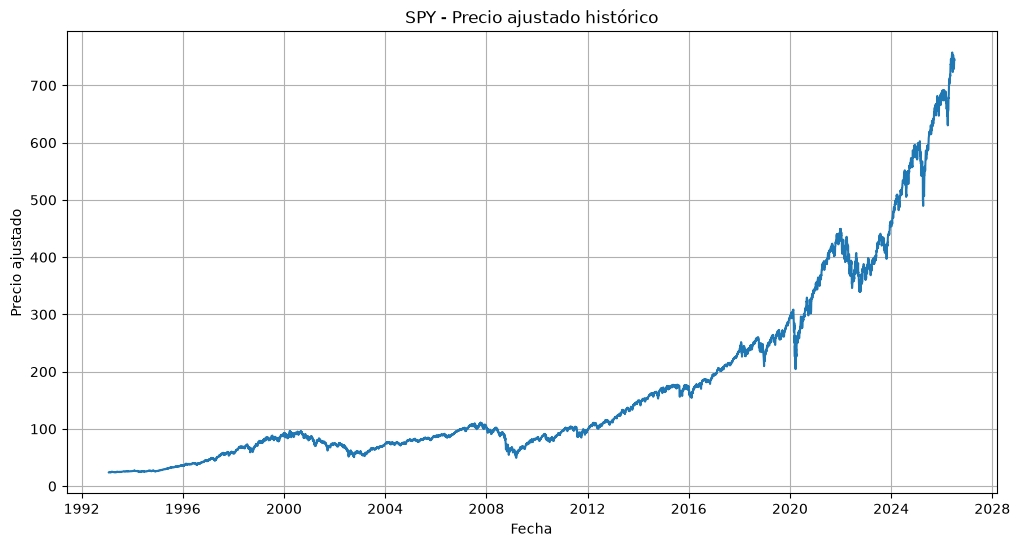

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(spy.index, spy["Adj Close"])
plt.title("SPY - Precio ajustado histórico")
plt.xlabel("Fecha")
plt.ylabel("Precio ajustado")
plt.grid(True)
plt.show()

## Observaciones iniciales

El precio ajustado de SPY muestra una tendencia creciente de largo plazo.

Se aprecian varios periodos de caídas importantes, especialmente durante crisis de mercado.

El gráfico también sugiere que la escala lineal puede hacer que los movimientos recientes parezcan visualmente más grandes que los movimientos antiguos.

En próximos análisis será necesario estudiar rendimientos y drawdowns, no solo precios.

Hoy calculamos:

1. Rendimiento simple diario
2. Rendimiento logarítmico diario
3. Estadísticas básicas
4. Histograma de rendimientos
5. Volatilidad anualizada

# Rendimientos diarios

En esta sección calculo los rendimientos diarios de SPY a partir del precio ajustado.

Usaré el precio ajustado (`Adj Close`) porque incorpora ajustes por dividendos, splits y otros eventos corporativos.

In [12]:
price = spy["Adj Close"].copy()

price.head()

Date
1993-01-29    24.113268
1993-02-01    24.284761
1993-02-02    24.336224
1993-02-03    24.593477
1993-02-04    24.696363
Name: Adj Close, dtype: float64

In [13]:
simple_returns = price.pct_change()

simple_returns.head()

Date
1993-01-29         NaN
1993-02-01    0.007112
1993-02-02    0.002119
1993-02-03    0.010571
1993-02-04    0.004183
Name: Adj Close, dtype: float64

In [15]:
import numpy as np

In [16]:
log_returns = np.log(price / price.shift(1))

log_returns.head()

Date
1993-01-29         NaN
1993-02-01    0.007087
1993-02-02    0.002117
1993-02-03    0.010515
1993-02-04    0.004175
Name: Adj Close, dtype: float64

In [17]:
returns = pd.DataFrame({
    "simple_return": simple_returns,
    "log_return": log_returns
})

returns = returns.dropna()

returns.head()

,simple_return,log_return
Date,,
1993-02-01,0.007112,0.007087
1993-02-02,0.002119,0.002117
1993-02-03,0.010571,0.010515
1993-02-04,0.004183,0.004175
1993-02-05,-0.000694,-0.000694


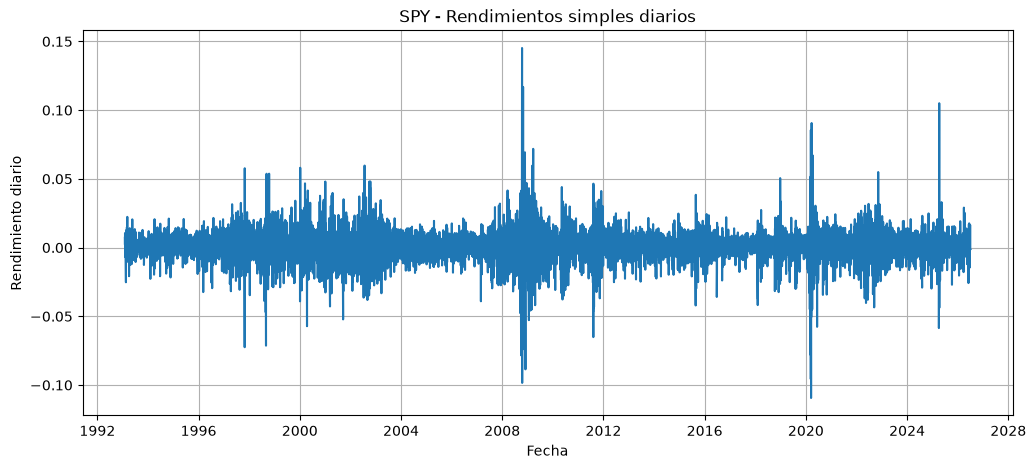

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(returns.index, returns["simple_return"])
plt.title("SPY - Rendimientos simples diarios")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento diario")
plt.grid(True)
plt.show()

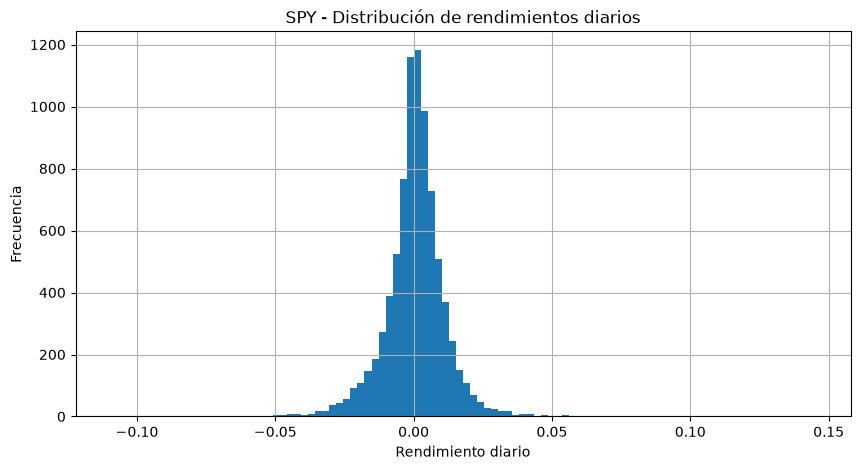

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(returns["simple_return"], bins=100)
plt.title("SPY - Distribución de rendimientos diarios")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

In [20]:
mean_daily_return = returns["simple_return"].mean()
std_daily_return = returns["simple_return"].std()
best_day = returns["simple_return"].max()
worst_day = returns["simple_return"].min()
positive_days = (returns["simple_return"] > 0).mean()
negative_days = (returns["simple_return"] < 0).mean()

summary_stats = pd.Series({
    "Media diaria": mean_daily_return,
    "Volatilidad diaria": std_daily_return,
    "Mejor día": best_day,
    "Peor día": worst_day,
    "% días positivos": positive_days,
    "% días negativos": negative_days
})

summary_stats

Media diaria          0.000476
Volatilidad diaria    0.011700
Mejor día             0.145198
Peor día             -0.109424
% días positivos      0.540894
% días negativos      0.451736
dtype: float64

In [21]:
summary_stats_percent = summary_stats * 100

summary_stats_percent

Media diaria           0.047635
Volatilidad diaria     1.170000
Mejor día             14.519751
Peor día             -10.942382
% días positivos      54.089396
% días negativos      45.173562
dtype: float64

In [22]:
trading_days = 252

annualized_volatility = std_daily_return * np.sqrt(trading_days)

annualized_volatility

np.float64(0.1857318039553563)

In [23]:
annualized_volatility * 100

np.float64(18.57318039553563)

## Observaciones sobre los rendimientos

Los rendimientos diarios de SPY fluctúan alrededor de cero.

La media diaria es pequeña en comparación con la volatilidad diaria, lo que indica que el ruido diario domina sobre la tendencia media de corto plazo.

El histograma muestra que la mayoría de rendimientos diarios están cerca de cero, pero existen días extremos positivos y negativos.

La volatilidad anualizada proporciona una primera medida del riesgo histórico de mantener SPY.

En próximos análisis será necesario estudiar drawdowns y comparar estos resultados con una estrategia buy and hold.

## Nota sobre rendimientos simples y logarítmicos

El rendimiento simple diario mide el cambio porcentual de precio entre dos días consecutivos:

R_t = P_t / P_{t-1} - 1

El rendimiento logarítmico se define como:

r_t = log(P_t / P_{t-1}) = log(1 + R_t)

Para movimientos pequeños, ambos son muy parecidos. La ventaja de los rendimientos logarítmicos es que son aditivos en el tiempo: la suma de los log-retornos diarios entre dos fechas es igual al logaritmo del cociente entre el precio final y el precio inicial.

En este análisis inicial calculo ambos, aunque para interpretar porcentajes diarios resulta más intuitivo mirar los rendimientos simples.

## Nota sobre volatilidad anualizada

La volatilidad diaria se calcula como la desviación estándar de los rendimientos diarios.

Para anualizarla se multiplica por sqrt(252), porque hay aproximadamente 252 sesiones bursátiles al año y la desviación estándar escala con la raíz del tiempo.

La fórmula usada es:

volatilidad anualizada = volatilidad diaria × sqrt(252)

Esta anualización es una aproximación que asume que los rendimientos diarios son suficientemente comparables e independientes. En la práctica, los mercados presentan cambios de régimen, clustering de volatilidad y eventos extremos.